<a href="https://colab.research.google.com/github/mashac136/RealTimeMachineLearning/blob/main/hw3_seqtoseq_machine_translation_MarlyAshac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()  # select vast_english_french.txt

Saving vast_english_french.txt to vast_english_french.txt


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter  # for counting word frequencies
import random
import numpy as np

# setting seeds to ensure same results every time
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


DATA_PATH = "/content/vast_english_french.txt"  # Colab

MAX_LEN    = 50   # ignore sentence pairs longer than 50 tokens
MIN_FREQ   = 2    # a word must appear at least twice to get its own vocab entry
BATCH_SIZE = 64   # number of sentence pairs per training batch
EPOCHS     = 20   # full passes over the training data

#   PAD = pads short sequences to the same length in a batch
#   SOS = start of sequence
#   EOS = mark where a sentence ends - end of sequence
#   UNK = replaces any word not seen during training (unknown)
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"

# converts words to integer indices so the model can work with numbers
class Vocab:
    def __init__(self):
        # start with the 4 special tokens always at fixed indices
        self.word2idx = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
        self.idx2word = {0: PAD, 1: SOS, 2: EOS, 3: UNK}

    def build(self, sentences, min_freq=MIN_FREQ):
        # count how often each word appears across all sentences
        counts = Counter(w for s in sentences for w in s)
        for word, freq in counts.items():
            # only add words that appear at least min_freq times
            if freq >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word

    def encode(self, tokens):
        # convert a list of word strings to list of integer indices
        # unknown words get mapped to the UNK index
        return [self.word2idx.get(t, self.word2idx[UNK]) for t in tokens]

    def __len__(self):
        return len(self.word2idx)

# load & clean the dataset
# file has one sentence pair per line
def load_data(path, max_len=MAX_LEN):
    eng_sentences, fra_sentences = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue  # skip bad lines
            # lowercase and split into word tokens
            eng = parts[0].lower().split()
            fra = parts[1].lower().split()
            # skip pairs where either side is too long
            if len(eng) <= max_len and len(fra) <= max_len:
                eng_sentences.append(eng)
                fra_sentences.append(fra)
    return eng_sentences, fra_sentences

eng_all, fra_all = load_data(DATA_PATH)
print(f"Total sentence pairs loaded: {len(eng_all)}")

# 80/20 train/val split — same split for all 3 problems
split_idx = int(0.8 * len(eng_all))
eng_train, eng_val = eng_all[:split_idx], eng_all[split_idx:]
fra_train, fra_val = fra_all[:split_idx], fra_all[split_idx:]
print(f"Train pairs: {len(eng_train)}  |  Val pairs: {len(eng_val)}")

# build vocab on training data only
src_vocab = Vocab()  # english vocabulary
tgt_vocab = Vocab()  # french vocabulary
src_vocab.build(eng_train)
tgt_vocab.build(fra_train)
print(f"English vocab size: {len(src_vocab)}  |  French vocab size: {len(tgt_vocab)}")

# PyTorch dataset
# wraps data so PyTorch's DataLoader can batch and shuffle it
class TranslationDataset(Dataset):
    def __init__(self, src_sents, tgt_sents, src_vocab, tgt_vocab):
        self.pairs = list(zip(src_sents, tgt_sents))
        self.sv = src_vocab
        self.tv = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        # encode source: word indices + EOS at the end
        src_ids = self.sv.encode(src) + [self.sv.word2idx[EOS]]
        # encode target: SOS at the start + word indices + EOS at the end
        tgt_ids = [self.tv.word2idx[SOS]] + self.tv.encode(tgt) + [self.tv.word2idx[EOS]]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

# sentences in a batch have different lengths — pad them to the same length
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(src_batch, batch_first=True,
                                         padding_value=src_vocab.word2idx[PAD])
    tgt_pad = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True,
                                         padding_value=tgt_vocab.word2idx[PAD])
    # move tensors to GPU
    return src_pad.to(device), tgt_pad.to(device)

# training loader shuffles data each epoch — validation loader does not
train_loader = DataLoader(
    TranslationDataset(eng_train, fra_train, src_vocab, tgt_vocab),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
val_loader = DataLoader(
    TranslationDataset(eng_val, fra_val, src_vocab, tgt_vocab),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

print("DataLoaders ready ✓")

# quick device check — both should say cuda
src, tgt = next(iter(train_loader))
print("src device:", src.device)
print("tgt device:", tgt.device)

Using device: cuda
Total sentence pairs loaded: 555
Train pairs: 444  |  Val pairs: 111
English vocab size: 353  |  French vocab size: 366
DataLoaders ready ✓
src device: cuda:0
tgt device: cuda:0


In [ ]:
# Hyperparameters
EMBED_DIM  = 256   # size of word embeddings (words are represented as 256-dim vectors)
HIDDEN_DIM = 512   # size of the GRU hidden state
N_LAYERS   = 2     # number of stacked GRU layers
DROPOUT    = 0.5   # dropout rate to prevent overfitting

# Encoder
# encoder reads the full English sentence and compresses it
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        # embedding layer: converts word indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=src_vocab.word2idx[PAD])
        # GRU to process the embedded sequence step by step
        self.gru = nn.GRU(embed_dim, hidden_dim, n_layers,
                          batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src shape: (batch_size, src_len)

        # embed the source tokens and apply dropout
        embedded = self.dropout(self.embedding(src))
        # embedded shape: (batch_size, src_len, embed_dim)

        # pass through GRU — only need the final hidden state
        outputs, hidden = self.gru(embedded)
        # hidden shape: (n_layers, batch_size, hidden_dim)
        # hidden it summarizes the whole sentence

        return hidden

# Decoder
# The decoder takes the context vector and generates the French sentence
# one word at a time
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        # embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=tgt_vocab.word2idx[PAD])
        # GRU
        self.gru = nn.GRU(embed_dim, hidden_dim, n_layers,
                          batch_first=True, dropout=dropout)
        # projects GRU output to probability over entire vocab
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden):
        # tgt_token shape: (batch_size,) — one token per sentence in the batch
        # hidden shape:    (n_layers, batch_size, hidden_dim)

        # add a time dimension so GRU sees it as a sequence of length 1
        tgt_token = tgt_token.unsqueeze(1)
        # shape: (batch_size, 1)

        # embed and apply dropout
        embedded = self.dropout(self.embedding(tgt_token))
        # shape: (batch_size, 1, embed_dim)

        # updates the hidden state
        output, hidden = self.gru(embedded, hidden)
        # output shape: (batch_size, 1, hidden_dim)

        # project to vocab size to get scores for each word
        prediction = self.fc(output.squeeze(1))
        # prediction shape: (batch_size, vocab_size)

        return prediction, hidden

# combine encoder and decoder into one model
# predicted word back as input
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_vocab = tgt_vocab

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src shape: (batch_size, src_len)
        # tgt shape: (batch_size, tgt_len)

        batch_size = src.shape[0]
        tgt_len    = tgt.shape[1]
        tgt_vocab_size = len(self.tgt_vocab)

        # tensor to store decoder outputs at each step
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(device)

        # encode the source sentence → get context vector
        hidden = self.encoder(src)

        # first decoder input is always the <sos> token
        dec_input = tgt[:, 0].to(device)

        # generate one word at a time
        for t in range(1, tgt_len):
            pred, hidden = self.decoder(dec_input, hidden)
            outputs[:, t, :] = pred

            # teacher forcing: use real target word or model's prediction
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t].to(device) if use_teacher else pred.argmax(1).to(device)
        return outputs

encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
decoder = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
model   = Seq2Seq(encoder, decoder, tgt_vocab).to(device)

# count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model built ✓  |  Trainable parameters: {total_params:,}")

Model built ✓  |  Trainable parameters: 5,889,134


Training for 20 epochs...

Epoch 01/20  |  Train Loss: 5.0097  |  Val Loss: 3.8730  |  Time: 1.1s
Epoch 02/20  |  Train Loss: 4.1140  |  Val Loss: 3.5735  |  Time: 0.2s
Epoch 03/20  |  Train Loss: 3.9247  |  Val Loss: 3.5025  |  Time: 0.2s
Epoch 04/20  |  Train Loss: 3.7316  |  Val Loss: 3.3388  |  Time: 0.2s
Epoch 05/20  |  Train Loss: 3.5345  |  Val Loss: 3.1707  |  Time: 0.2s
Epoch 06/20  |  Train Loss: 3.3274  |  Val Loss: 3.0669  |  Time: 0.2s
Epoch 07/20  |  Train Loss: 3.1573  |  Val Loss: 3.1082  |  Time: 0.2s
Epoch 08/20  |  Train Loss: 3.0003  |  Val Loss: 3.0165  |  Time: 0.2s
Epoch 09/20  |  Train Loss: 2.9040  |  Val Loss: 2.8719  |  Time: 0.2s
Epoch 10/20  |  Train Loss: 2.7545  |  Val Loss: 2.8161  |  Time: 0.2s
Epoch 11/20  |  Train Loss: 2.6474  |  Val Loss: 2.7963  |  Time: 0.2s
Epoch 12/20  |  Train Loss: 2.5310  |  Val Loss: 2.7856  |  Time: 0.2s
Epoch 13/20  |  Train Loss: 2.4697  |  Val Loss: 3.0215  |  Time: 0.2s
Epoch 14/20  |  Train Loss: 2.3811  |  Val Loss: 2

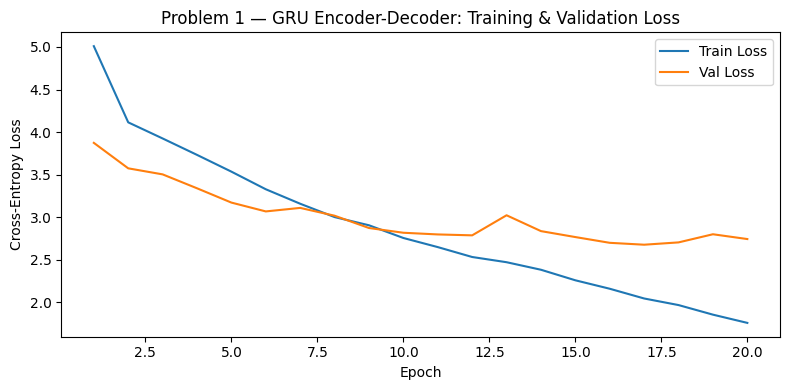

Loss curve saved ✓


In [ ]:
# training loop
import time
import matplotlib.pyplot as plt

# ignore PAD tokens when computing loss
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.word2idx[PAD])

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# training function (one epoch)
def train_epoch(model, loader, optimizer, criterion):
    model.train()  # set model to training mode (enables dropout)
    epoch_loss = 0

    for src, tgt in loader:
        optimizer.zero_grad()  # clear gradients from previous step

        # forward pass
        output = model(src, tgt, teacher_forcing_ratio=0.5)
        # output shape: (batch_size, tgt_len, tgt_vocab_size)

        # reshape for loss computation:
        # output: (batch_size * tgt_len, vocab_size)
        # tgt:    (batch_size * tgt_len,)
        # skip the first token since we never predict it
        output = output[:, 1:, :].reshape(-1, len(tgt_vocab))
        tgt    = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()   # compute gradients

        # clip gradients to prevent exploding gradient problem
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()  # update weights
        epoch_loss += loss.item()

    # return average loss across all batches
    return epoch_loss / len(loader)

# validation function
def val_epoch(model, loader, criterion):
    model.eval()  # set model to eval mode (disables dropout)
    epoch_loss = 0

    with torch.no_grad():  # no gradient computation needed for validation
        for src, tgt in loader:
            # no  forcing during validation (ratio = 0)
            output = model(src, tgt, teacher_forcing_ratio=0.0)
            output = output[:, 1:, :].reshape(-1, len(tgt_vocab))
            tgt    = tgt[:, 1:].reshape(-1)
            loss   = criterion(output, tgt)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

# main training loop
train_losses = []  # track loss each epoch for plotting
val_losses   = []

print(f"Training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = val_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - start
    print(f"Epoch {epoch:02d}/{EPOCHS}  |  "
          f"Train Loss: {train_loss:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  |  "
          f"Time: {elapsed:.1f}s")

# plot training & validation loss curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 1 — GRU Encoder-Decoder: Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("p1_loss_curve.png", dpi=150)  # save for report
plt.show()
print("Loss curve saved ✓")

In [ ]:
# evalutation — Sequence Accuracy & BLEU Score


from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

# greedy decode function ────────────────────────────────────────────────────
# takes a single English sentence  and returns model's predicted French translation
def greedy_decode(model, sentence, src_vocab, tgt_vocab, max_len=50):
    model.eval()
    with torch.no_grad():
        # encode the source sentence into indices and move to device
        src_ids = src_vocab.encode(sentence) + [src_vocab.word2idx[EOS]]
        src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)  # (1, src_len)

        # encode — get context vector
        hidden = model.encoder(src_tensor)

        # start decoding with SOS token
        dec_input = torch.tensor([tgt_vocab.word2idx[SOS]]).to(device)

        predicted_words = []
        for _ in range(max_len):
            pred, hidden = model.decoder(dec_input, hidden)
            # pick the highest scoring word
            top_token = pred.argmax(1).item()

            # stop if we hit EOS
            if top_token == tgt_vocab.word2idx[EOS]:
                break

            predicted_words.append(tgt_vocab.idx2word[top_token])
            dec_input = torch.tensor([top_token]).to(device)

    return predicted_words

# evaluate on full validation set
def evaluate(model, eng_val, fra_val, src_vocab, tgt_vocab):
    exact_matches = 0       # counts perfect word-for-word matches
    references    = []      # list of reference translations for BLEU
    hypotheses    = []      # list of model predictions for BLEU

    for src_sent, tgt_sent in zip(eng_val, fra_val):
        # get model prediction
        pred = greedy_decode(model, src_sent, src_vocab, tgt_vocab)

        # sequence accuracy: check if prediction exactly matches target
        if pred == tgt_sent:
            exact_matches += 1

        # BLEU expects references as list of list of words
        references.append([tgt_sent])
        hypotheses.append(pred)

    # sequence accuracy = % of exact matches
    seq_accuracy = exact_matches / len(eng_val) * 100

    # BLEU score
    smoothing = SmoothingFunction().method1
    bleu = corpus_bleu(references, hypotheses, smoothing_function=smoothing) * 100

    return seq_accuracy, bleu

# run evaluation
seq_acc, bleu = evaluate(model, eng_val, fra_val, src_vocab, tgt_vocab)

print("=" * 50)
print("Problem 1 — GRU Baseline Evaluation Results")
print("=" * 50)
print(f"Traditional Sequence Accuracy : {seq_acc:.2f}%")
print(f"Validation BLEU-4 Score       : {bleu:.2f}")
print("=" * 50)

Problem 1 — GRU Baseline Evaluation Results
Traditional Sequence Accuracy : 0.00%
Validation BLEU-4 Score       : 3.52


In [ ]:
# validation

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothing = SmoothingFunction().method1

# pick 5 random sentences from the validation set to test
random.seed(42)
sample_indices = random.sample(range(len(eng_val)), 5)

print("=" * 70)
print("Problem 1 — GRU Baseline: Sample Translations")
print("=" * 70)

for i, idx in enumerate(sample_indices):
    src_sent  = eng_val[idx]   # original english sentence
    tgt_sent  = fra_val[idx]   # correct french translation
    pred_sent = greedy_decode(model, src_sent, src_vocab, tgt_vocab)

    # check if prediction is exact match
    exact = "✓" if pred_sent == tgt_sent else "✗"

    # compute individual sentence BLEU score
    bleu_score = sentence_bleu([tgt_sent], pred_sent,
                                smoothing_function=smoothing) * 100

    print(f"\nExample {i+1}:")
    print(f"  English  : {' '.join(src_sent)}")
    print(f"  Target   : {' '.join(tgt_sent)}")
    print(f"  Predicted: {' '.join(pred_sent) if pred_sent else '[empty]'}")
    print(f"  Exact Match: {exact}  |  BLEU: {bleu_score:.2f}")

print("\n" + "=" * 70)

Problem 1 — GRU Baseline: Sample Translations

Example 1:
  English  : the business hotel is situated near the center
  Target   : l'hôtel d'affaires est situé près du centre
  Predicted: le <unk> <unk> est <unk> <unk> <unk> <unk>
  Exact Match: ✗  |  BLEU: 2.78

Example 2:
  English  : he replies to all customer emails immediately
  Target   : il répond immédiatement à tous les e-mails des clients
  Predicted: il a <unk> de <unk> <unk> <unk> <unk> <unk> <unk>
  Exact Match: ✗  |  BLEU: 2.11

Example 3:
  English  : i want a cold glass of iced coffee
  Target   : je veux un verre froid de café glacé
  Predicted: je veux une <unk> de <unk> <unk> <unk>
  Exact Match: ✗  |  BLEU: 6.50

Example 4:
  English  : i see a helicopter flying over the city
  Target   : je vois un hélicoptère voler au-dessus de la ville
  Predicted: j'ai reçu un <unk> <unk> <unk> <unk> <unk>
  Exact Match: ✗  |  BLEU: 2.45

Example 5:
  English  : he speaks six international languages completely fluently
  Target 

In [ ]:
#Problem 2

In [ ]:


# encoder with hidden state outputs
#return ALL hidden states
#  attention mechanism looks at every position in the source sentence
class AttentionEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=src_vocab.word2idx[PAD])
        self.gru = nn.GRU(embed_dim, hidden_dim, n_layers,
                          batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src shape: (batch_size, src_len)
        embedded = self.dropout(self.embedding(src))

        # outputs = all hidden states at every time step
        # hidden  = final hidden state (used to init decoder)
        outputs, hidden = self.gru(embedded)
        # outputs shape: (batch_size, src_len, hidden_dim)
        # hidden shape:  (n_layers, batch_size, hidden_dim)

        return outputs, hidden

# at each decoder step - computes a weighted sum over all encoder hidden states
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # combines decoder hidden state + encoder outputs to produce attention scores
        self.attn    = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v       = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden shape:  (batch_size, hidden_dim) — current decoder state
        # encoder_outputs shape: (batch_size, src_len, hidden_dim)

        src_len = encoder_outputs.shape[1]

        # repeat decoder hidden state once per source token so we can compare
        decoder_hidden = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)
        # decoder_hidden shape: (batch_size, src_len, hidden_dim)

        # concatenate decoder hidden with each encoder output and score them
        energy = torch.tanh(self.attn(
            torch.cat((decoder_hidden, encoder_outputs), dim=2)
        ))
        # energy shape: (batch_size, src_len, hidden_dim)

        # squeeze to scalar score per source token
        attention_scores = self.v(energy).squeeze(2)
        # attention_scores shape: (batch_size, src_len)

        # softmax so scores sum to 1 — these are the attention weights
        return torch.softmax(attention_scores, dim=1)

# attention decoder
# uses attention weights to build a context vector from encoder
# outputs, then combines it with the current input to generate the next word
class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.attention = Attention(hidden_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=tgt_vocab.word2idx[PAD])
        # input to GRU is embedding + context vector concatenated
        self.gru = nn.GRU(embed_dim + hidden_dim, hidden_dim, n_layers,
                          batch_first=True, dropout=dropout)
        # project GRU output + context vector to vocab size
        self.fc  = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, encoder_outputs):
        # tgt_token shape:       (batch_size,)
        # hidden shape:          (n_layers, batch_size, hidden_dim)
        # encoder_outputs shape: (batch_size, src_len, hidden_dim)

        tgt_token = tgt_token.unsqueeze(1)
        embedded  = self.dropout(self.embedding(tgt_token))
        # embedded shape: (batch_size, 1, embed_dim)

        # use the top decoder layer hidden state for attention
        attn_weights = self.attention(hidden[-1], encoder_outputs)
        # attn_weights shape: (batch_size, src_len)

        # weighted sum of encoder outputs = context vector
        attn_weights = attn_weights.unsqueeze(1)
        context = torch.bmm(attn_weights, encoder_outputs)
        # context shape: (batch_size, 1, hidden_dim)


        gru_input = torch.cat((embedded, context), dim=2)
        # gru_input shape: (batch_size, 1, embed_dim + hidden_dim)

        output, hidden = self.gru(gru_input, hidden)
        # output shape: (batch_size, 1, hidden_dim)

        #  GRU output and context for final prediction
        prediction = self.fc(
            torch.cat((output.squeeze(1), context.squeeze(1)), dim=1)
        )
        # prediction shape: (batch_size, vocab_size)

        return prediction, hidden, attn_weights.squeeze(1)

# Attention Seq2Seq
class AttentionSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab):
        super().__init__()
        self.encoder  = encoder
        self.decoder  = decoder
        self.tgt_vocab = tgt_vocab

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size     = src.shape[0]
        tgt_len        = tgt.shape[1]
        tgt_vocab_size = len(self.tgt_vocab)

        # store all decoder outputs
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(device)

        # encode — get all hidden states + final hidden for decoder init
        encoder_outputs, hidden = self.encoder(src)

        # first decoder input is SOS token
        dec_input = tgt[:, 0].to(device)

        for t in range(1, tgt_len):
            pred, hidden, _ = self.decoder(dec_input, hidden, encoder_outputs)
            outputs[:, t, :] = pred

            # teacher forcing
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t].to(device) if use_teacher else pred.argmax(1)

        return outputs

attn_encoder = AttentionEncoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
attn_decoder = AttentionDecoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
attn_model   = AttentionSeq2Seq(attn_encoder, attn_decoder, tgt_vocab).to(device)

total_params = sum(p.numel() for p in attn_model.parameters() if p.requires_grad)
print(f"Attention model built ✓  |  Trainable parameters: {total_params:,}")

Attention model built ✓  |  Trainable parameters: 7,388,270


Training attention model for 20 epochs...

Epoch 01/20  |  Train Loss: 5.0599  |  Val Loss: 3.8405  |  Time: 0.4s
Epoch 02/20  |  Train Loss: 4.1134  |  Val Loss: 3.5482  |  Time: 0.4s
Epoch 03/20  |  Train Loss: 3.8022  |  Val Loss: 3.2966  |  Time: 0.6s
Epoch 04/20  |  Train Loss: 3.5065  |  Val Loss: 3.1219  |  Time: 1.7s
Epoch 05/20  |  Train Loss: 3.2137  |  Val Loss: 2.9633  |  Time: 0.4s
Epoch 06/20  |  Train Loss: 2.9270  |  Val Loss: 2.9113  |  Time: 0.3s
Epoch 07/20  |  Train Loss: 2.7130  |  Val Loss: 2.8298  |  Time: 0.3s
Epoch 08/20  |  Train Loss: 2.5317  |  Val Loss: 2.7507  |  Time: 0.3s
Epoch 09/20  |  Train Loss: 2.3865  |  Val Loss: 2.6881  |  Time: 0.3s
Epoch 10/20  |  Train Loss: 2.2138  |  Val Loss: 2.6819  |  Time: 0.3s
Epoch 11/20  |  Train Loss: 2.0693  |  Val Loss: 2.6526  |  Time: 0.3s
Epoch 12/20  |  Train Loss: 1.9353  |  Val Loss: 2.5770  |  Time: 0.3s
Epoch 13/20  |  Train Loss: 1.7513  |  Val Loss: 2.5778  |  Time: 0.3s
Epoch 14/20  |  Train Loss: 1.6233

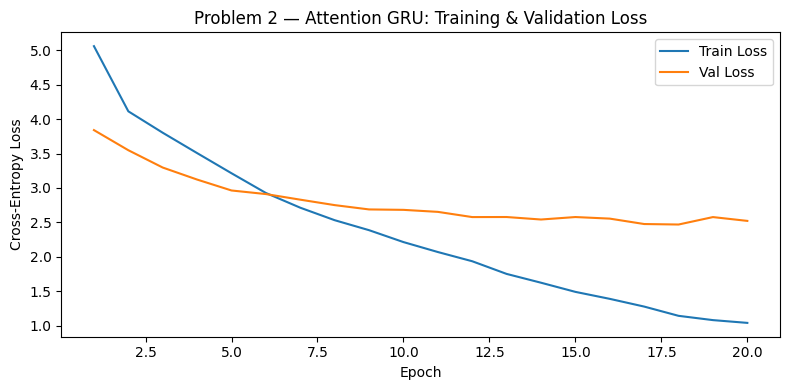

Loss curve saved ✓


In [ ]:
# training

# loss function & optimizer for attention model
attn_criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.word2idx[PAD])
attn_optimizer = torch.optim.Adam(attn_model.parameters(), lr=0.001)

# training loop
attn_train_losses = []
attn_val_losses   = []

print(f"Training attention model for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    # train one epoch
    attn_model.train()
    train_loss = 0
    for src, tgt in train_loader:
        attn_optimizer.zero_grad()
        output = attn_model(src, tgt, teacher_forcing_ratio=0.5)
        output = output[:, 1:, :].reshape(-1, len(tgt_vocab))
        tgt_y  = tgt[:, 1:].reshape(-1)
        loss   = attn_criterion(output, tgt_y)
        loss.backward()
        nn.utils.clip_grad_norm_(attn_model.parameters(), max_norm=1.0)
        attn_optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # validate one epoch
    attn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            output = attn_model(src, tgt, teacher_forcing_ratio=0.0)
            output = output[:, 1:, :].reshape(-1, len(tgt_vocab))
            tgt_y  = tgt[:, 1:].reshape(-1)
            val_loss += attn_criterion(output, tgt_y).item()
    val_loss /= len(val_loader)

    attn_train_losses.append(train_loss)
    attn_val_losses.append(val_loss)

    elapsed = time.time() - start
    print(f"Epoch {epoch:02d}/{EPOCHS}  |  "
          f"Train Loss: {train_loss:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  |  "
          f"Time: {elapsed:.1f}s")

# plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), attn_train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), attn_val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 2 — Attention GRU: Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("p2_loss_curve.png", dpi=150)  # save for report
plt.show()
print("Loss curve saved ✓")

In [ ]:

#  greedy decode for attention model
# also collect attention weights at each step

def greedy_decode_attention(model, sentence, src_vocab, tgt_vocab, max_len=50):
    model.eval()
    with torch.no_grad():
        # encode source sentence
        src_ids    = src_vocab.encode(sentence) + [src_vocab.word2idx[EOS]]
        src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)

        # get all encoder hidden states
        encoder_outputs, hidden = model.encoder(src_tensor)

        # start with SOS token
        dec_input = torch.tensor([tgt_vocab.word2idx[SOS]]).to(device)

        predicted_words  = []
        all_attn_weights = []  # store attention weights for visualization

        for _ in range(max_len):
            pred, hidden, attn_weights = model.decoder(dec_input, hidden, encoder_outputs)

            # store attention weights for this decoding step
            all_attn_weights.append(attn_weights.squeeze(0).cpu().numpy())

            top_token = pred.argmax(1).item()

            # stop at EOS
            if top_token == tgt_vocab.word2idx[EOS]:
                break

            predicted_words.append(tgt_vocab.idx2word[top_token])
            dec_input = torch.tensor([top_token]).to(device)

    return predicted_words, all_attn_weights

# evaluate on full validation set
def evaluate_attention(model, eng_val, fra_val, src_vocab, tgt_vocab):
    exact_matches = 0
    references    = []
    hypotheses    = []

    for src_sent, tgt_sent in zip(eng_val, fra_val):
        pred, _ = greedy_decode_attention(model, src_sent, src_vocab, tgt_vocab)

        if pred == tgt_sent:
            exact_matches += 1

        references.append([tgt_sent])
        hypotheses.append(pred)

    seq_accuracy = exact_matches / len(eng_val) * 100
    smoothing    = SmoothingFunction().method1
    bleu         = corpus_bleu(references, hypotheses, smoothing_function=smoothing) * 100

    return seq_accuracy, bleu

# run evaluation
attn_seq_acc, attn_bleu = evaluate_attention(attn_model, eng_val, fra_val, src_vocab, tgt_vocab)

print("=" * 50)
print("Problem 2 — Attention Model Evaluation Results")
print("=" * 50)
print(f"Traditional Sequence Accuracy : {attn_seq_acc:.2f}%")
print(f"Validation BLEU-4 Score       : {attn_bleu:.2f}")
print("=" * 50)

# ── Side by side comparison with Problem 1 ───────────────────────────────────
print("\nComparison with Problem 1 Baseline:")
print(f"  Sequence Accuracy — Baseline: {seq_acc:.2f}%  |  Attention: {attn_seq_acc:.2f}%")
print(f"  BLEU-4 Score      — Baseline: {bleu:.2f}      |  Attention: {attn_bleu:.2f}")

Problem 2 — Attention Model Evaluation Results
Traditional Sequence Accuracy : 0.00%
Validation BLEU-4 Score       : 5.44

Comparison with Problem 1 Baseline:
  Sequence Accuracy — Baseline: 0.00%  |  Attention: 0.00%
  BLEU-4 Score      — Baseline: 3.52      |  Attention: 5.44



Visualization 1:
  English  : the birds gather dry twigs for their nests
  Target   : les oiseaux ramassent des brindilles sèches pour leurs nids
  Predicted: les oiseaux <unk> <unk> <unk> <unk> les <unk> <unk>


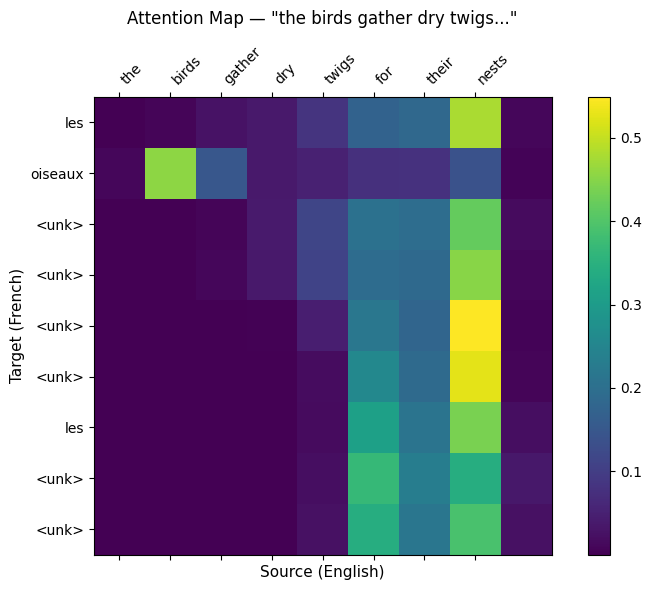

Saved: p2_attention_map_1.png

Visualization 2:
  English  : we crossed the wide river using a wooden raft
  Target   : nous avons traversé la large rivière en utilisant un radeau en bois
  Predicted: nous avons <unk> la <unk> de <unk> de <unk> de <unk>


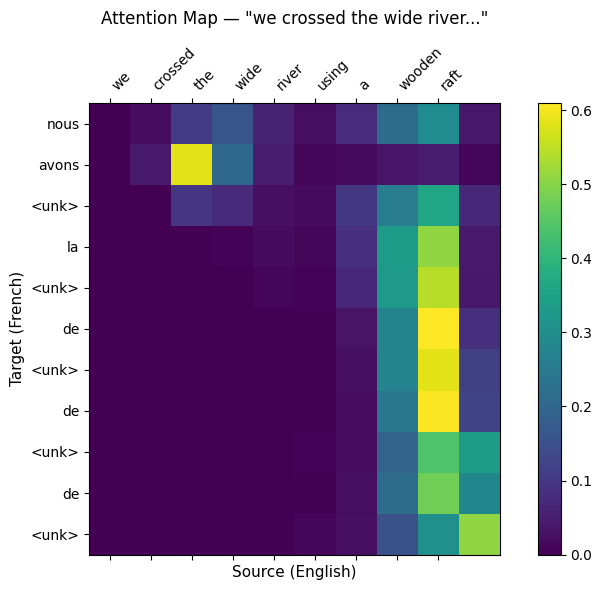

Saved: p2_attention_map_2.png


In [ ]:
import matplotlib.ticker as ticker
import numpy as np

def plot_attention(src_words, tgt_words, attn_weights, title, filename):
    # attn_weights = list of arrays, one per decoding step
    # each array has length = src_len
    # stack into matrix of shape (tgt_len, src_len)
    attn_matrix = np.array(attn_weights[:len(tgt_words)])

    fig, ax = plt.subplots(figsize=(8, 6))

    # plot heatmap — brighter = more attention on that word
    cax = ax.matshow(attn_matrix, cmap="viridis")
    fig.colorbar(cax)

    # label axes with words
    ax.set_xticks(range(len(src_words)))
    ax.set_yticks(range(len(tgt_words)))
    ax.set_xticklabels(src_words, rotation=45, ha='left', fontsize=10)
    ax.set_yticklabels(tgt_words, fontsize=10)

    ax.set_xlabel("Source (English)", fontsize=11)
    ax.set_ylabel("Target (French)", fontsize=11)
    ax.set_title(title, fontsize=12, pad=15)

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved: {filename}")

# pick 2 sample sentences from validation set for visualization
# try a few until we get two good ones
viz_indices = [2, 4]  # using examples 3 and 5 from earlier

for i, idx in enumerate(viz_indices):
    src_sent  = eng_val[idx]
    tgt_sent  = fra_val[idx]

    # get prediction and attention weights
    pred, attn_weights = greedy_decode_attention(
        attn_model, src_sent, src_vocab, tgt_vocab
    )

    print(f"\nVisualization {i+1}:")
    print(f"  English  : {' '.join(src_sent)}")
    print(f"  Target   : {' '.join(tgt_sent)}")
    print(f"  Predicted: {' '.join(pred) if pred else '[empty]'}")

    if len(pred) == 0:
        print("  Skipping — empty prediction")
        continue

    plot_attention(
        src_words   = src_sent,
        tgt_words   = pred,
        attn_weights= attn_weights,
        title       = f"Attention Map — \"{' '.join(src_sent[:5])}...\"",
        filename    = f"p2_attention_map_{i+1}.png"
    )


In [ ]:

# attention Model Sample Translations


print("=" * 70)
print("Problem 2 — Attention Model: Sample Translations")
print("=" * 70)

# use the same 5 sample indices as Problem 1 for direct comparison
for i, idx in enumerate(sample_indices):
    src_sent  = eng_val[idx]   # original english sentence
    tgt_sent  = fra_val[idx]   # correct french translation
    pred, _   = greedy_decode_attention(attn_model, src_sent, src_vocab, tgt_vocab)

    # check if prediction is exact match
    exact = "✓" if pred == tgt_sent else "✗"

    # compute individual sentence BLEU score
    bleu_score = sentence_bleu([tgt_sent], pred,
                                smoothing_function=smoothing) * 100

    print(f"\nExample {i+1}:")
    print(f"  English  : {' '.join(src_sent)}")
    print(f"  Target   : {' '.join(tgt_sent)}")
    print(f"  Predicted: {' '.join(pred) if pred else '[empty]'}")
    print(f"  Exact Match: {exact}  |  BLEU: {bleu_score:.2f}")

print("\n" + "=" * 70)

Problem 2 — Attention Model: Sample Translations

Example 1:
  English  : the business hotel is situated near the center
  Target   : l'hôtel d'affaires est situé près du centre
  Predicted: le <unk> <unk> est est <unk> <unk> <unk>
  Exact Match: ✗  |  BLEU: 2.78

Example 2:
  English  : he replies to all customer emails immediately
  Target   : il répond immédiatement à tous les e-mails des clients
  Predicted: il a <unk> de <unk> de <unk> <unk> <unk> <unk> <unk>
  Exact Match: ✗  |  BLEU: 1.89

Example 3:
  English  : i want a cold glass of iced coffee
  Target   : je veux un verre froid de café glacé
  Predicted: j'ai veux une nouvelle de de de <unk> de mon
  Exact Match: ✗  |  BLEU: 2.51

Example 4:
  English  : i see a helicopter flying over the city
  Target   : je vois un hélicoptère voler au-dessus de la ville
  Predicted: je vois un <unk> <unk> dans le ciel
  Exact Match: ✗  |  BLEU: 12.13

Example 5:
  English  : he speaks six international languages completely fluently
  Tar

In [ ]:
#Problem 3

In [ ]:

# reverse direction (French to English)

# swap source and target — French is now the source, English is the target
# we use the SAME dataset splits as Problems 1 and 2 for fair comparison

# build reversed vocabularies on training data only
fra_vocab = Vocab()  # French vocabulary (now source)
eng_vocab = Vocab()  # English vocabulary (now target)
fra_vocab.build(fra_train)  # French sentences as source
eng_vocab.build(eng_train)  # English sentences as target
print(f"French (src) vocab size: {len(fra_vocab)}  |  English (tgt) vocab size: {len(eng_vocab)}")

# reversed dataloaders
# French to English train loader
rev_train_loader = DataLoader(
    TranslationDataset(fra_train, eng_train, fra_vocab, eng_vocab),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda batch: collate_fn_rev(batch)
)
# French to English val loader
rev_val_loader = DataLoader(
    TranslationDataset(fra_val, eng_val, fra_vocab, eng_vocab),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda batch: collate_fn_rev(batch)
)

# reversed collate function
# same as before but uses the reversed vocabularies
def collate_fn_rev(batch):
    src_batch, tgt_batch = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(src_batch, batch_first=True,
                                         padding_value=fra_vocab.word2idx[PAD])
    tgt_pad = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True,
                                         padding_value=eng_vocab.word2idx[PAD])
    # move to GPU
    return src_pad.to(device), tgt_pad.to(device)

# rebuild loaders with correct collate function
# redefine now that collate_fn_rev is declared
rev_train_loader = DataLoader(
    TranslationDataset(fra_train, eng_train, fra_vocab, eng_vocab),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_rev
)
rev_val_loader = DataLoader(
    TranslationDataset(fra_val, eng_val, fra_vocab, eng_vocab),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_rev
)

# quick device check
src, tgt = next(iter(rev_train_loader))
print(f"Sample batch — src: {src.shape}  tgt: {tgt.shape}  device: {src.device}")
print("Reversed DataLoaders ready ✓")

French (src) vocab size: 366  |  English (tgt) vocab size: 353
Sample batch — src: torch.Size([64, 14])  tgt: torch.Size([64, 11])  device: cuda:0
Reversed DataLoaders ready ✓


Reversed baseline model built ✓  |  Trainable parameters: 5,882,465

Training reversed baseline GRU for 20 epochs...

Epoch 01/20  |  Train Loss: 4.9516  |  Val Loss: 3.6444  |  Time: 0.3s
Epoch 02/20  |  Train Loss: 4.0124  |  Val Loss: 3.4063  |  Time: 0.3s
Epoch 03/20  |  Train Loss: 3.8118  |  Val Loss: 3.2902  |  Time: 0.2s
Epoch 04/20  |  Train Loss: 3.6529  |  Val Loss: 3.2187  |  Time: 0.2s
Epoch 05/20  |  Train Loss: 3.5297  |  Val Loss: 3.1203  |  Time: 0.3s
Epoch 06/20  |  Train Loss: 3.4099  |  Val Loss: 3.0836  |  Time: 0.6s
Epoch 07/20  |  Train Loss: 3.2644  |  Val Loss: 3.0638  |  Time: 0.2s
Epoch 08/20  |  Train Loss: 3.1297  |  Val Loss: 2.9962  |  Time: 0.2s
Epoch 09/20  |  Train Loss: 2.9867  |  Val Loss: 2.7846  |  Time: 0.2s
Epoch 10/20  |  Train Loss: 2.8742  |  Val Loss: 2.8129  |  Time: 0.2s
Epoch 11/20  |  Train Loss: 2.7809  |  Val Loss: 2.6938  |  Time: 0.2s
Epoch 12/20  |  Train Loss: 2.6876  |  Val Loss: 2.7540  |  Time: 0.2s
Epoch 13/20  |  Train Loss: 2.

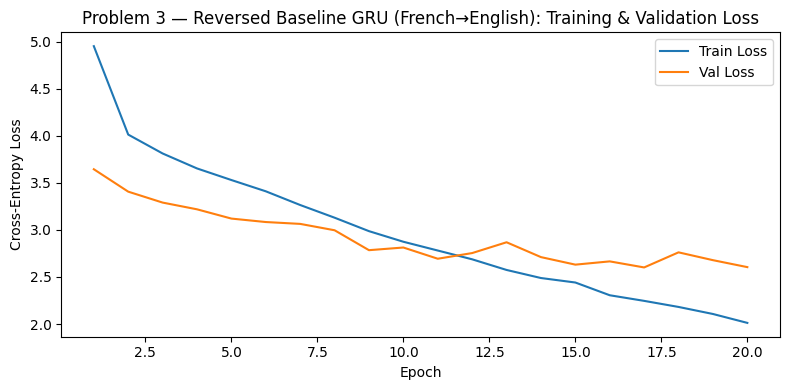

Loss curve saved ✓


In [ ]:

# fresh baseline model with reversed vocab sizes
# French is source vocab - English is target vocab
rev_encoder = Encoder(len(fra_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
rev_decoder = Decoder(len(eng_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
rev_model   = Seq2Seq(rev_encoder, rev_decoder, eng_vocab).to(device)

total_params = sum(p.numel() for p in rev_model.parameters() if p.requires_grad)
print(f"Reversed baseline model built ✓  |  Trainable parameters: {total_params:,}")

# loss & optimizer
rev_criterion = nn.CrossEntropyLoss(ignore_index=eng_vocab.word2idx[PAD])
rev_optimizer = torch.optim.Adam(rev_model.parameters(), lr=0.001)

#training loop
rev_train_losses = []
rev_val_losses   = []

print(f"\nTraining reversed baseline GRU for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    # train one epoch
    rev_model.train()
    train_loss = 0
    for src, tgt in rev_train_loader:
        rev_optimizer.zero_grad()
        output = rev_model(src, tgt, teacher_forcing_ratio=0.5)
        output = output[:, 1:, :].reshape(-1, len(eng_vocab))
        tgt_y  = tgt[:, 1:].reshape(-1)
        loss   = rev_criterion(output, tgt_y)
        loss.backward()
        nn.utils.clip_grad_norm_(rev_model.parameters(), max_norm=1.0)
        rev_optimizer.step()
        train_loss += loss.item()
    train_loss /= len(rev_train_loader)

    # validate one epoch
    rev_model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in rev_val_loader:
            output = rev_model(src, tgt, teacher_forcing_ratio=0.0)
            output = output[:, 1:, :].reshape(-1, len(eng_vocab))
            tgt_y  = tgt[:, 1:].reshape(-1)
            val_loss += rev_criterion(output, tgt_y).item()
    val_loss /= len(rev_val_loader)

    rev_train_losses.append(train_loss)
    rev_val_losses.append(val_loss)

    elapsed = time.time() - start
    print(f"Epoch {epoch:02d}/{EPOCHS}  |  "
          f"Train Loss: {train_loss:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  |  "
          f"Time: {elapsed:.1f}s")

# plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), rev_train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), rev_val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 3 — Reversed Baseline GRU (French→English): Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("p3_baseline_loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved ✓")

Reversed attention model built ✓  |  Trainable parameters: 7,374,945

Training reversed attention GRU for 20 epochs...

Epoch 01/20  |  Train Loss: 4.9225  |  Val Loss: 3.6852  |  Time: 0.3s
Epoch 02/20  |  Train Loss: 4.0051  |  Val Loss: 3.3186  |  Time: 0.3s
Epoch 03/20  |  Train Loss: 3.6761  |  Val Loss: 3.2024  |  Time: 0.3s
Epoch 04/20  |  Train Loss: 3.4128  |  Val Loss: 2.9662  |  Time: 0.3s
Epoch 05/20  |  Train Loss: 3.0920  |  Val Loss: 2.8223  |  Time: 0.3s
Epoch 06/20  |  Train Loss: 2.8285  |  Val Loss: 2.8370  |  Time: 0.3s
Epoch 07/20  |  Train Loss: 2.6381  |  Val Loss: 2.7663  |  Time: 0.3s
Epoch 08/20  |  Train Loss: 2.4695  |  Val Loss: 2.6883  |  Time: 0.3s
Epoch 09/20  |  Train Loss: 2.2849  |  Val Loss: 2.5712  |  Time: 0.3s
Epoch 10/20  |  Train Loss: 2.1413  |  Val Loss: 2.4411  |  Time: 0.3s
Epoch 11/20  |  Train Loss: 2.0375  |  Val Loss: 2.5706  |  Time: 0.3s
Epoch 12/20  |  Train Loss: 1.8994  |  Val Loss: 2.4783  |  Time: 0.3s
Epoch 13/20  |  Train Loss: 

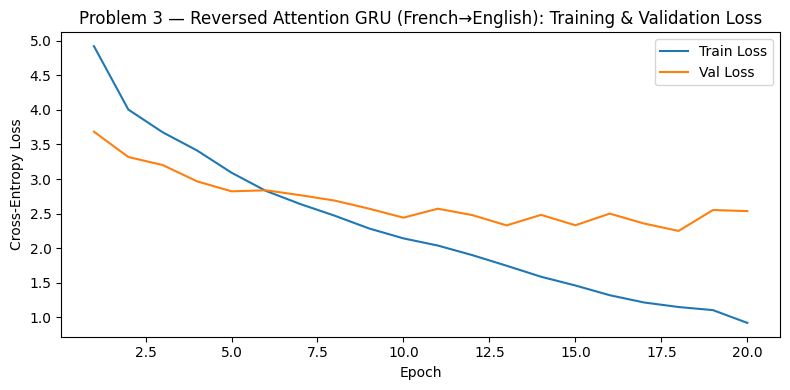

Loss curve saved ✓


In [ ]:

# attention model with reversed vocab sizes
rev_attn_encoder = AttentionEncoder(len(fra_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
rev_attn_decoder = AttentionDecoder(len(eng_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)
rev_attn_model   = AttentionSeq2Seq(rev_attn_encoder, rev_attn_decoder, eng_vocab).to(device)

total_params = sum(p.numel() for p in rev_attn_model.parameters() if p.requires_grad)
print(f"Reversed attention model built ✓  |  Trainable parameters: {total_params:,}")

# loss & optimizer
rev_attn_criterion = nn.CrossEntropyLoss(ignore_index=eng_vocab.word2idx[PAD])
rev_attn_optimizer = torch.optim.Adam(rev_attn_model.parameters(), lr=0.001)

# training loop
rev_attn_train_losses = []
rev_attn_val_losses   = []

print(f"\nTraining reversed attention GRU for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    # train one epoch
    rev_attn_model.train()
    train_loss = 0
    for src, tgt in rev_train_loader:
        rev_attn_optimizer.zero_grad()
        output = rev_attn_model(src, tgt, teacher_forcing_ratio=0.5)
        output = output[:, 1:, :].reshape(-1, len(eng_vocab))
        tgt_y  = tgt[:, 1:].reshape(-1)
        loss   = rev_attn_criterion(output, tgt_y)
        loss.backward()
        nn.utils.clip_grad_norm_(rev_attn_model.parameters(), max_norm=1.0)
        rev_attn_optimizer.step()
        train_loss += loss.item()
    train_loss /= len(rev_train_loader)

    # validate one epoch
    rev_attn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in rev_val_loader:
            output = rev_attn_model(src, tgt, teacher_forcing_ratio=0.0)
            output = output[:, 1:, :].reshape(-1, len(eng_vocab))
            tgt_y  = tgt[:, 1:].reshape(-1)
            val_loss += rev_attn_criterion(output, tgt_y).item()
    val_loss /= len(rev_val_loader)

    rev_attn_train_losses.append(train_loss)
    rev_attn_val_losses.append(val_loss)

    elapsed = time.time() - start
    print(f"Epoch {epoch:02d}/{EPOCHS}  |  "
          f"Train Loss: {train_loss:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  |  "
          f"Time: {elapsed:.1f}s")

# ── plot loss curves ──────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), rev_attn_train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), rev_attn_val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 3 — Reversed Attention GRU (French→English): Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("p3_attention_loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved ✓")

In [ ]:

# greedy decode for reversed baseline (French to English)
def greedy_decode_rev(model, sentence, src_vocab, tgt_vocab, max_len=50):
    model.eval()
    with torch.no_grad():
        # encode French source sentence
        src_ids    = src_vocab.encode(sentence) + [src_vocab.word2idx[EOS]]
        src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)
        hidden     = model.encoder(src_tensor)

        # start decoding with SOS
        dec_input     = torch.tensor([tgt_vocab.word2idx[SOS]]).to(device)
        predicted_words = []

        for _ in range(max_len):
            pred, hidden = model.decoder(dec_input, hidden)
            top_token    = pred.argmax(1).item()
            if top_token == tgt_vocab.word2idx[EOS]:
                break
            predicted_words.append(tgt_vocab.idx2word[top_token])
            dec_input = torch.tensor([top_token]).to(device)

    return predicted_words

# greedy decode for reversed attention (French to English)
def greedy_decode_rev_attention(model, sentence, src_vocab, tgt_vocab, max_len=50):
    model.eval()
    with torch.no_grad():
        src_ids         = src_vocab.encode(sentence) + [src_vocab.word2idx[EOS]]
        src_tensor      = torch.tensor(src_ids).unsqueeze(0).to(device)
        encoder_outputs, hidden = model.encoder(src_tensor)

        dec_input       = torch.tensor([tgt_vocab.word2idx[SOS]]).to(device)
        predicted_words = []

        for _ in range(max_len):
            pred, hidden, _ = model.decoder(dec_input, hidden, encoder_outputs)
            top_token       = pred.argmax(1).item()
            if top_token == tgt_vocab.word2idx[EOS]:
                break
            predicted_words.append(tgt_vocab.idx2word[top_token])
            dec_input = torch.tensor([top_token]).to(device)

    return predicted_words

# evaluate both models on reversed validation set
def evaluate_rev(model, decode_fn, fra_val, eng_val, fra_vocab, eng_vocab):
    exact_matches = 0
    references    = []
    hypotheses    = []

    for src_sent, tgt_sent in zip(fra_val, eng_val):
        pred = decode_fn(model, src_sent, fra_vocab, eng_vocab)
        if pred == tgt_sent:
            exact_matches += 1
        references.append([tgt_sent])
        hypotheses.append(pred)

    seq_accuracy = exact_matches / len(fra_val) * 100
    smoothing    = SmoothingFunction().method1
    bleu         = corpus_bleu(references, hypotheses, smoothing_function=smoothing) * 100
    return seq_accuracy, bleu

# run evaluation
rev_seq_acc,      rev_bleu      = evaluate_rev(rev_model,      greedy_decode_rev,
                                               fra_val, eng_val, fra_vocab, eng_vocab)
rev_attn_seq_acc, rev_attn_bleu = evaluate_rev(rev_attn_model, greedy_decode_rev_attention,
                                               fra_val, eng_val, fra_vocab, eng_vocab)

print("=" * 60)
print("Problem 3 — Reversed Models Evaluation Results")
print("=" * 60)
print(f"Baseline GRU  (French→English) — Seq Acc: {rev_seq_acc:.2f}%  |  BLEU: {rev_bleu:.2f}")
print(f"Attention GRU (French→English) — Seq Acc: {rev_attn_seq_acc:.2f}%  |  BLEU: {rev_attn_bleu:.2f}")
print("=" * 60)

# full comparison table across all 4 models
print("\nFull Comparison — All Models:")
print(f"  P1 Baseline  (Eng→Fra) — Seq Acc: {seq_acc:.2f}%  |  BLEU: {bleu:.2f}")
print(f"  P2 Attention (Eng→Fra) — Seq Acc: {attn_seq_acc:.2f}%  |  BLEU: {attn_bleu:.2f}")
print(f"  P3 Baseline  (Fra→Eng) — Seq Acc: {rev_seq_acc:.2f}%  |  BLEU: {rev_bleu:.2f}")
print(f"  P3 Attention (Fra→Eng) — Seq Acc: {rev_attn_seq_acc:.2f}%  |  BLEU: {rev_attn_bleu:.2f}")

# qualitative examples — both models on same 5 French sentences
print("\n" + "=" * 70)
print("Problem 3 — Qualitative Validation: French → English Translations")
print("=" * 70)

# use same sample indices as before for consistency
for i, idx in enumerate(sample_indices):
    fra_sent = fra_val[idx]   # French source sentence
    eng_sent = eng_val[idx]   # correct English target

    pred_base = greedy_decode_rev(rev_model, fra_sent, fra_vocab, eng_vocab)
    pred_attn = greedy_decode_rev_attention(rev_attn_model, fra_sent, fra_vocab, eng_vocab)

    bleu_base = sentence_bleu([eng_sent], pred_base, smoothing_function=SmoothingFunction().method1) * 100
    bleu_attn = sentence_bleu([eng_sent], pred_attn, smoothing_function=SmoothingFunction().method1) * 100

    print(f"\nExample {i+1}:")
    print(f"  French   : {' '.join(fra_sent)}")
    print(f"  Target   : {' '.join(eng_sent)}")
    print(f"  Baseline : {' '.join(pred_base) if pred_base else '[empty]'}  |  BLEU: {bleu_base:.2f}")
    print(f"  Attention: {' '.join(pred_attn) if pred_attn else '[empty]'}  |  BLEU: {bleu_attn:.2f}")

print("\n" + "=" * 70)

Problem 3 — Reversed Models Evaluation Results
Baseline GRU  (French→English) — Seq Acc: 0.00%  |  BLEU: 1.32
Attention GRU (French→English) — Seq Acc: 0.00%  |  BLEU: 8.87

Full Comparison — All Models:
  P1 Baseline  (Eng→Fra) — Seq Acc: 0.00%  |  BLEU: 3.52
  P2 Attention (Eng→Fra) — Seq Acc: 0.00%  |  BLEU: 5.44
  P3 Baseline  (Fra→Eng) — Seq Acc: 0.00%  |  BLEU: 1.32
  P3 Attention (Fra→Eng) — Seq Acc: 0.00%  |  BLEU: 8.87

Problem 3 — Qualitative Validation: French → English Translations

Example 1:
  French   : l'hôtel d'affaires est situé près du centre
  Target   : the business hotel is situated near the center
  Baseline : the <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>  |  BLEU: 2.40
  Attention: the <unk> <unk> is <unk> <unk> is <unk>  |  BLEU: 3.30

Example 2:
  French   : il répond immédiatement à tous les e-mails des clients
  Target   : he replies to all customer emails immediately
  Baseline : he <unk> <unk> <unk> <unk> <unk> <unk> <unk>  |  BLEU: 2.78
  Attention: